In [1]:
from functions import *

/c/Users/White/Desktop/GTP-DE/Amalitech-Projects/week4/PySpark-Project/new/functions.py:289: SyntaxWarning: invalid escape sequence '\|'
  df_split = df.withColumn("genres", split(col("genres"), "\|"))


In [2]:
'''create spark session'''

spark = create_spark_session("TMDB-PySpark")

25/04/25 00:59:47 WARN Utils: Your hostname, White resolves to a loopback address: 127.0.1.1; using 172.21.2.26 instead (on interface eth0)
25/04/25 00:59:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/25 00:59:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
''' load .env file in this directory'''
load_dotenv()


'''get api key and save the base url'''
api_key = os.getenv('TMDB_API_KEY')

url = 'https://api.themoviedb.org/3/movie'


In [4]:
'''list of movies to fetch from API'''

movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397, 
             420818, 24428, 168259, 99861, 284054, 12445, 181808, 
             330457, 351286, 109445, 321612, 260513]


In [5]:
%time df_movies = extract_data(url, api_key, movie_ids, spark)

[WARNING] HTTP error for movie ID 0: 404 Client Error: Not Found for url: https://api.themoviedb.org/3/movie/0?api_key=6383d74ea1616df62e4286bc3cb11c82&append_to_response=credits
[INFO] Fetched movie ID 299534 successfully.
[INFO] Fetched movie ID 19995 successfully.
[INFO] Fetched movie ID 140607 successfully.
[INFO] Fetched movie ID 299536 successfully.
[INFO] Fetched movie ID 597 successfully.
[INFO] Fetched movie ID 135397 successfully.
[INFO] Fetched movie ID 420818 successfully.
[INFO] Fetched movie ID 24428 successfully.
[INFO] Fetched movie ID 168259 successfully.
[INFO] Fetched movie ID 99861 successfully.
[INFO] Fetched movie ID 284054 successfully.
[INFO] Fetched movie ID 12445 successfully.
[INFO] Fetched movie ID 181808 successfully.
[INFO] Fetched movie ID 330457 successfully.
[INFO] Fetched movie ID 351286 successfully.
[INFO] Fetched movie ID 109445 successfully.
[INFO] Fetched movie ID 321612 successfully.
[INFO] Fetched movie ID 260513 successfully.


CPU times: user 251 ms, sys: 25.6 ms, total: 277 ms
Wall time: 22.5 s


In [6]:
df_movies.toPandas().head(1)

25/04/25 01:01:23 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,adult,backdrop_path,belongs_to_collection,budget,credits,genres,homepage,id,imdb_id,origin_country,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"(/zuW6fOiusv4X9nnW3paHGfXcSll.jpg, 86311, The ...",356000000,"([(False, 493, Tony Stark / Iron Man, 5e85cd73...","[(12, Adventure), (878, Science Fiction), (28,...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],...,2019-04-24,2799439100,181,"[(English, en, English), (Japanese, ja, 日本語), ...",Released,Avenge the fallen.,Avengers: Endgame,False,8.237,26258


In [7]:
'''Clean Dataframe'''

df_movies = clean_data(df_movies)

In [8]:
df_movies.toPandas().head(2)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_million_usd,revenue_million_usd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.44,Marvel Studios,...,8.24,47.74,181,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Joe Russo|Anthony Russo,593
1,19995,Avatar,Enter the world of Pandora.,2009-12-15,Action|Adventure|Fantasy|Science Fiction,Avatar Collection,en,237.0,2923.71,Dune Entertainment|Lightstorm Entertainment|20...,...,7.59,26.57,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,986


In [9]:
'''KPI Analysis'''

#add kpi indicators
df_movies = kpi_indicators(df_movies)

In [10]:
df_movies.show(1)

[Stage 8:>                                                          (0 + 4) / 4]

+------+-----------------+------------------+------------+--------------------+---------------------+-----------------+------------------+-------------------+--------------------+--------------------+----------+------------+----------+-------+--------------------+--------------------+--------------------+--------------------+---------+--------------------+---------+-------+-----------------+
|    id|            title|           tagline|release_date|              genres|belongs_to_collection|original_language|budget_million_usd|revenue_million_usd|production_companies|production_countries|vote_count|vote_average|popularity|runtime|            overview|    spoken_languages|         poster_path|                cast|cast_size|            director|crew_size| profit|              roi|
+------+-----------------+------------------+------------+--------------------+---------------------+-----------------+------------------+-------------------+--------------------+--------------------+----------

In [12]:
'''KPI Analysis'''

# Highest Revenue
highest_revenue = rank_movies_spark(df_movies, sort_by="revenue_million_usd", ascending=False)
print("Highest Revenue Movies:")
highest_revenue.show()

# Highest Budget
highest_budget = rank_movies_spark(df_movies, sort_by="budget_million_usd", ascending=False)
print("\nHighest Budget Movies:")
highest_budget.show()

# Highest Profit (Revenue - Budget)
highest_profit = rank_movies_spark(df_movies.withColumn("profit", col("revenue_million_usd") - col("budget_million_usd")), sort_by="profit", ascending=False)
print("\nHighest Profit Movies:")
highest_profit.show()

# Lowest Profit (Revenue - Budget)
lowest_profit = rank_movies_spark(df_movies.withColumn("profit", col("revenue_million_usd") - col("budget_million_usd")), sort_by="profit", ascending=True)
print("\nLowest Profit Movies:")
lowest_profit.show()

# Highest ROI (Revenue / Budget) (only movies with Budget ≥ 10M)
highest_roi = rank_movies_spark(df_movies, sort_by="roi", ascending=False, min_budget_million_usd=10.0)
print("\nHighest ROI Movies (Budget >= 10M):")
highest_roi.show()

# Lowest ROI (only movies with Budget ≥ 10M)
lowest_roi = rank_movies_spark(df_movies, sort_by="roi", ascending=True, min_budget_million_usd=10.0)
print("\nLowest ROI Movies (Budget >= 10M):")
lowest_roi.show()

# Most Voted Movies
most_voted = rank_movies_spark(df_movies, sort_by="vote_count", ascending=False)
print("\nMost Voted Movies:")
most_voted.show()

# Highest Rated Movies (only movies with ≥10 votes)
highest_rated = rank_movies_spark(df_movies, sort_by="vote_average", ascending=False, min_votes=10)
print("\nHighest Rated Movies (>= 10 votes):")
highest_rated.show()

# Lowest Rated Movies (only movies with ≥10 votes)
lowest_rated = rank_movies_spark(df_movies, sort_by="vote_average", ascending=True, min_votes=10)
print("\nLowest Rated Movies (>= 10 votes):")
lowest_rated.show()

# Most Popular Movies
most_popular = rank_movies_spark(df_movies, sort_by="popularity", ascending=False)
print("\nMost Popular Movies:")
most_popular.show()

Highest Revenue Movies:


+-----------------+-------------------+
|            title|revenue_million_usd|
+-----------------+-------------------+
|           Avatar|            2923.71|
|Avengers: Endgame|            2799.44|
|          Titanic|            2264.16|
+-----------------+-------------------+


Highest Budget Movies:


+--------------------+------------------+
|               title|budget_million_usd|
+--------------------+------------------+
|Avengers: Age of ...|             365.0|
|   Avengers: Endgame|             356.0|
|Avengers: Infinit...|             300.0|
+--------------------+------------------+


Highest Profit Movies:


+-----------------+-------+
|            title| profit|
+-----------------+-------+
|           Avatar|2686.71|
|Avengers: Endgame|2443.44|
|          Titanic|2064.16|
+-----------------+-------+


Lowest Profit Movies:


+--------------------+-------+
|               title| profit|
+--------------------+-------+
|Avengers: Age of ...| 1040.4|
|       Incredibles 2|1042.81|
|Beauty and the Beast|1106.12|
+--------------------+-------+


Highest ROI Movies (Budget >= 10M):


...

+--------------------+----------+
|               title|vote_count|
+--------------------+----------+
|              Avatar|     32163|
|        The Avengers|     31635|
|Avengers: Infinit...|     30442|
+--------------------+----------+


Highest Rated Movies (>= 10 votes):


+--------------------+------------+
|               title|vote_average|
+--------------------+------------+
|Avengers: Infinit...|        8.24|
|   Avengers: Endgame|        8.24|
|Harry Potter and ...|        8.09|
+--------------------+------------+


Lowest Rated Movies (>= 10 votes):


+--------------------+------------+
|               title|vote_average|
+--------------------+------------+
|Jurassic World: F...|        6.54|
|      Jurassic World|        6.69|
|Star Wars: The La...|        6.78|
+--------------------+------------+


Most Popular Movies:


[Stage 38:>                                                         (0 + 4) / 4]

+--------------------+----------+
|               title|popularity|
+--------------------+----------+
|Avengers: Infinit...|     87.92|
|       The Lion King|     53.52|
|       Black Panther|     51.86|
+--------------------+----------+



In [13]:
"""Advanced Filtering"""


print("Best-Rated Science Fiction Action Movies Starring Bruce Willis:")
bruce_willis_movie(df_movies)

print("\nMovies Starring Uma Thurman Directed by Quentin Tarantino (Sorted by Runtime):")
uma_tarentino(df_movies)

Best-Rated Science Fiction Action Movies Starring Bruce Willis:


[Stage 41:>                                                         (0 + 4) / 4]

+-----+------------+
|title|vote_average|
+-----+------------+
+-----+------------+


Movies Starring Uma Thurman Directed by Quentin Tarantino (Sorted by Runtime):


[Stage 42:===========================================>              (3 + 1) / 4]

+-----+-------+
|title|runtime|
+-----+-------+
+-----+-------+



In [14]:
'''Comparing Franchises to Standalones'''

print("Comparing Franchise vs. Standalone Movie Performance:")
franchise_vs_standalone_performance(df_movies)



Comparing Franchise vs. Standalone Movie Performance:


[Stage 43:>                                                         (0 + 4) / 4]

+------------+-----------------------+-----------------+----------------------+------------------+------------------+
|is_franchise|avg_revenue_million_usd|median_roi       |avg_budget_million_usd|avg_popularity    |avg_vote_average  |
+------------+-----------------------+-----------------+----------------------+------------------+------------------+
|Franchise   |1682.6431250000003     |7.708647058823529|219.875               |33.03625          |7.3812500000000005|
|Standalone  |1765.1399999999999     |7.91325          |180.0                 |47.775000000000006|7.4399999999999995|
+------------+-----------------------+-----------------+----------------------+------------------+------------------+



In [18]:
'''Most successful franchises'''


print("Most Successful Movie Franchises (by Total Revenue):")
successful_franchises(df_movies, top_n=5) # You can change top_n to show more or fewer franchises


Most Successful Movie Franchises (by Total Revenue):


[Stage 61:>                                                         (0 + 4) / 4]

+------------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|belongs_to_collection   |num_movies|total_budget_million_usd|avg_budget_million_usd|total_revenue_million_usd|avg_revenue_million_usd|avg_vote_average|
+------------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|The Avengers Collection |4         |1241.0                  |310.25                |7776.08                  |1944.02                |7.8725          |
|Star Wars Collection    |2         |445.0                   |222.5                 |3400.92                  |1700.46                |7.02            |
|Jurassic Park Collection|2         |320.0                   |160.0                 |2982.01                  |1491.005               |6.615           |
|Avatar Collection       |1         |237.0                   |237.0               

In [20]:
'''Most Successful Directors'''
print("Most Successful Directors:")
successful_directors(df_movies, top_n=5) # You can adjust top_n as needed

Most Successful Directors:


[Stage 67:>                                                         (0 + 4) / 4]

+-----------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|director               |num_movies|total_budget_million_usd|avg_budget_million_usd|total_revenue_million_usd|avg_revenue_million_usd|avg_vote_average|
+-----------------------+----------+------------------------+----------------------+-------------------------+-----------------------+----------------+
|James Cameron          |2         |437.0                   |218.5                 |5187.87                  |2593.935               |7.75            |
|Joe Russo|Anthony Russo|2         |656.0                   |328.0                 |4851.860000000001        |2425.9300000000003     |8.24            |
|J.J. Abrams            |1         |245.0                   |245.0                 |2068.22                  |2068.22                |7.26            |
|Colin Trevorrow        |1         |150.0                   |150.0                 |1671

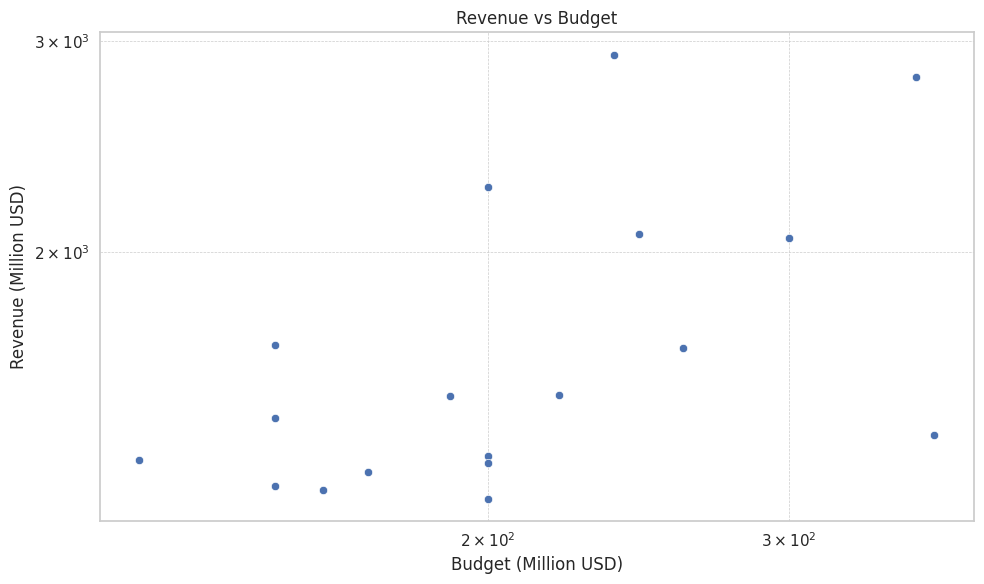

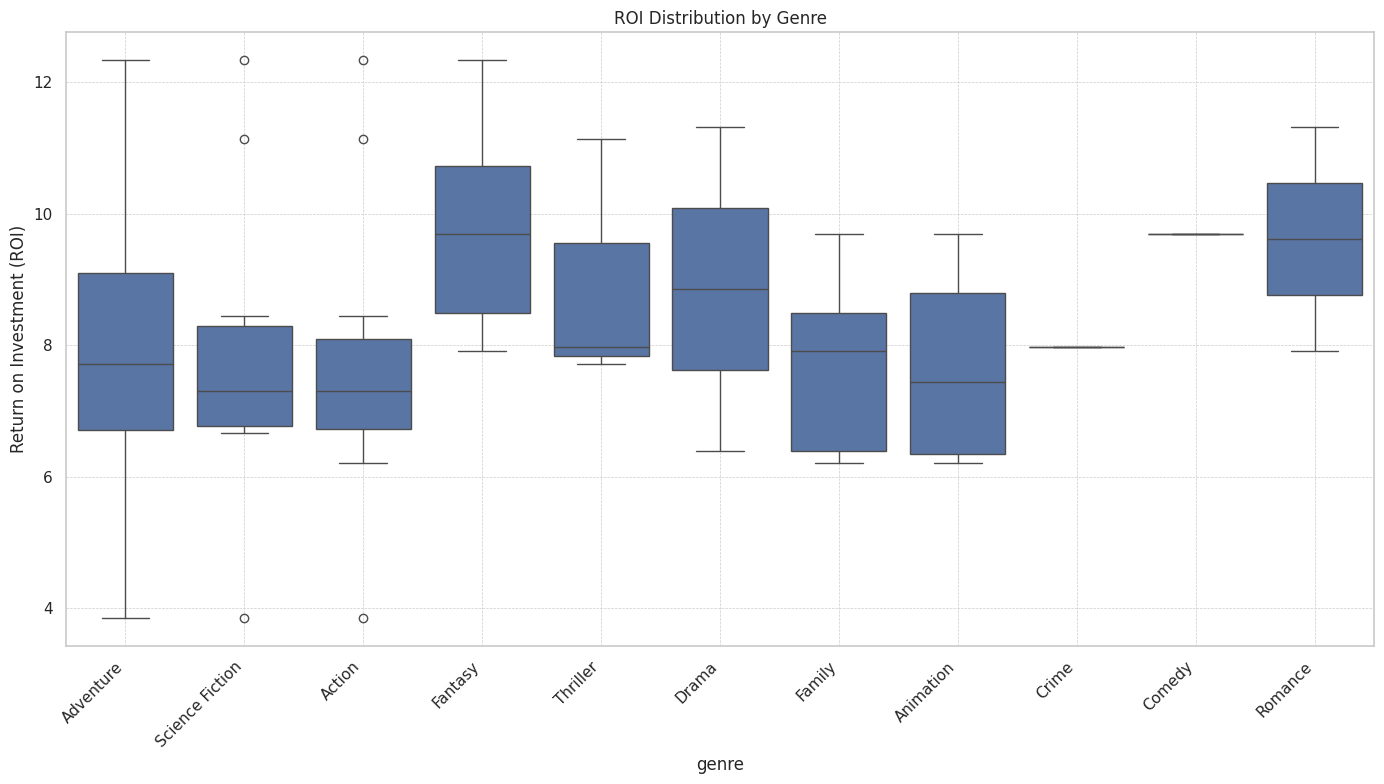

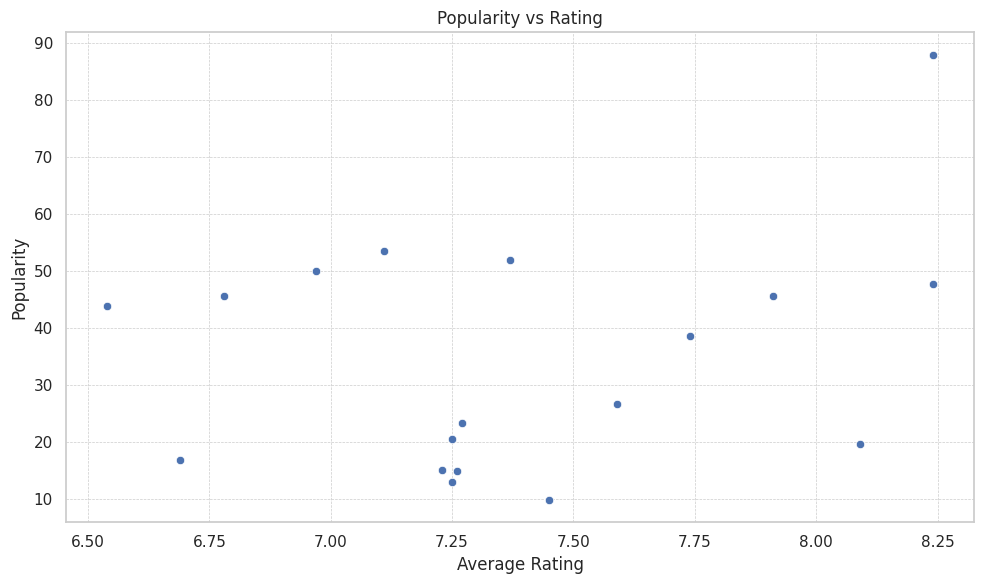

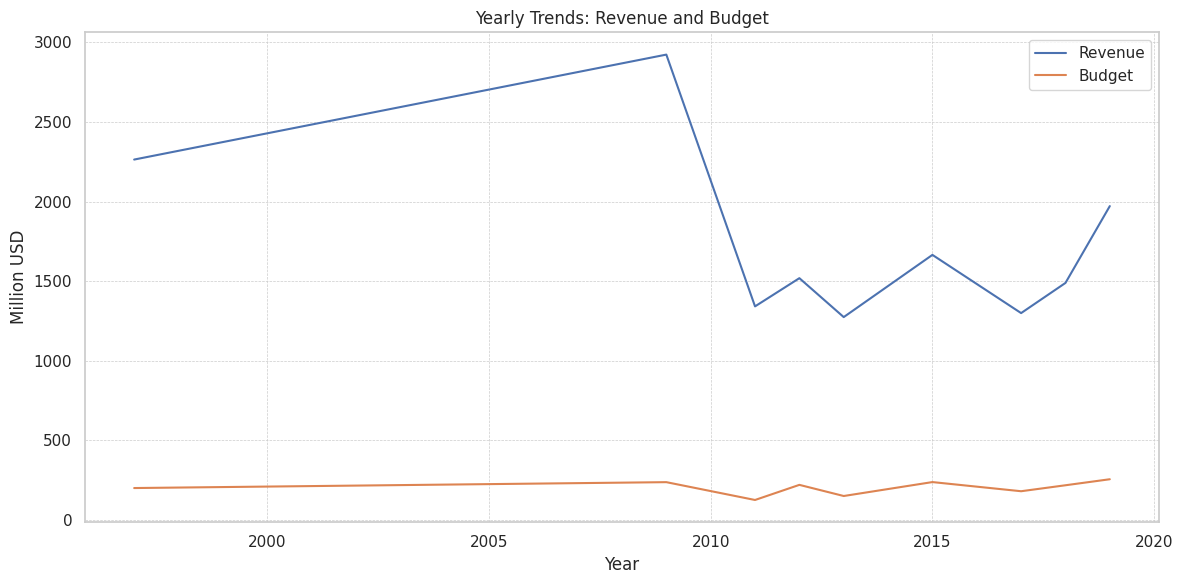

NameError: name 'pdf' is not defined

In [21]:
'''Visualizations'''
visualize_movies(df_movies)